In [20]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import warnings
warnings.filterwarnings("ignore")

In [21]:
df = pd.read_csv("enhanced_house_price_dataset.csv")
df.head()

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating,Price
0,1260,4,3,2,1,24,Pune,Semi-Furnished,Yes,Yes,Yes,Both,No,Company,4,1274350
1,5790,2,1,1,1,7,Kolkata,Unfurnished,Yes,Yes,Yes,Both,Yes,Bachelor,5,1094846
2,5626,5,2,3,0,15,Chennai,Semi-Furnished,No,Yes,Yes,Corporation,Yes,Company,6,1495933
3,5591,1,1,1,1,47,Delhi,Furnished,Yes,No,Yes,Borewell,No,Company,3,1003442
4,4172,5,1,1,1,44,Delhi,Unfurnished,No,No,No,Borewell,Yes,Bachelor,1,1306676


In [22]:
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Area              2000 non-null   int64 
 1   Bedrooms          2000 non-null   int64 
 2   Bathrooms         2000 non-null   int64 
 3   Stories           2000 non-null   int64 
 4   Parking           2000 non-null   int64 
 5   Age               2000 non-null   int64 
 6   City              2000 non-null   object
 7   Furnishing        2000 non-null   object
 8   Main Road         2000 non-null   object
 9   Guest Room        2000 non-null   object
 10  Basement          2000 non-null   object
 11  Water Supply      2000 non-null   object
 12  Air Conditioning  2000 non-null   object
 13  Preferred Tenant  2000 non-null   object
 14  Locality Rating   2000 non-null   int64 
 15  Price             2000 non-null   int64 
dtypes: int64(8), object(8)
memory usage: 250.1+ KB


np.int64(0)

In [23]:
def data_quality_report(df):
    report = pd.DataFrame({
        "Missing %": df.isnull().mean() * 100,
        "Unique Values": df.nunique(),
        "Data Type": df.dtypes
    })
    return report.sort_values(by="Missing %", ascending=False)

data_quality_report(df)

,Missing %,Unique Values,Data Type
Area,0.0,1686,int64
Bedrooms,0.0,5,int64
Bathrooms,0.0,3,int64
Stories,0.0,3,int64
Parking,0.0,3,int64
Age,0.0,50,int64
City,0.0,7,object
Furnishing,0.0,3,object
Main Road,0.0,2,object
Guest Room,0.0,2,object


In [24]:
df.describe()

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Locality Rating,Price
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,3238.081000,3.031000,2.02150,1.996000,0.990500,24.008500,5.357500,1.245014e+06
std,1604.510239,1.427255,0.81263,0.811981,0.806682,14.319076,2.843015,3.001744e+05
min,401.000000,1.000000,1.00000,1.000000,0.000000,0.000000,1.000000,3.346350e+05
25%,1860.000000,2.000000,1.00000,1.000000,0.000000,12.000000,3.000000,1.035278e+06
50%,3271.500000,3.000000,2.00000,2.000000,1.000000,24.000000,5.000000,1.246602e+06
75%,4599.750000,4.000000,3.00000,3.000000,2.000000,36.000000,8.000000,1.453607e+06
max,5996.000000,5.000000,3.00000,3.000000,2.000000,49.000000,10.000000,2.225409e+06


In [25]:
df.mean(numeric_only=True)
df.median(numeric_only=True)
df.mode().iloc[0]

,0
Area,1652
Bedrooms,4.0
Bathrooms,3.0
Stories,2.0
Parking,1.0
Age,32.0
City,Mumbai
Furnishing,Semi-Furnished
Main Road,Yes
Guest Room,Yes


In [26]:
df.std(numeric_only=True)
df.var(numeric_only=True)

df.max(numeric_only=True) - df.min(numeric_only=True)

,0
Area,5595
Bedrooms,4
Bathrooms,2
Stories,2
Parking,2
Age,49
Locality Rating,9
Price,1890774


In [27]:
df.min(numeric_only=True)
df.max(numeric_only=True)
df.quantile([0.25, 0.5, 0.75], numeric_only=True)

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Locality Rating,Price
0.25,1860.00,2.0,1.0,1.0,0.0,12.0,3.0,1035277.75
0.50,3271.50,3.0,2.0,2.0,1.0,24.0,5.0,1246602.00
0.75,4599.75,4.0,3.0,3.0,2.0,36.0,8.0,1453606.75


In [28]:
df.skew(numeric_only=True)
df.kurtosis(numeric_only=True)

,0
Area,-1.177028
Bedrooms,-1.320531
Bathrooms,-1.484625
Stories,-1.483184
Parking,-1.462971
Age,-1.157115
Locality Rating,-1.196216
Price,-0.172623


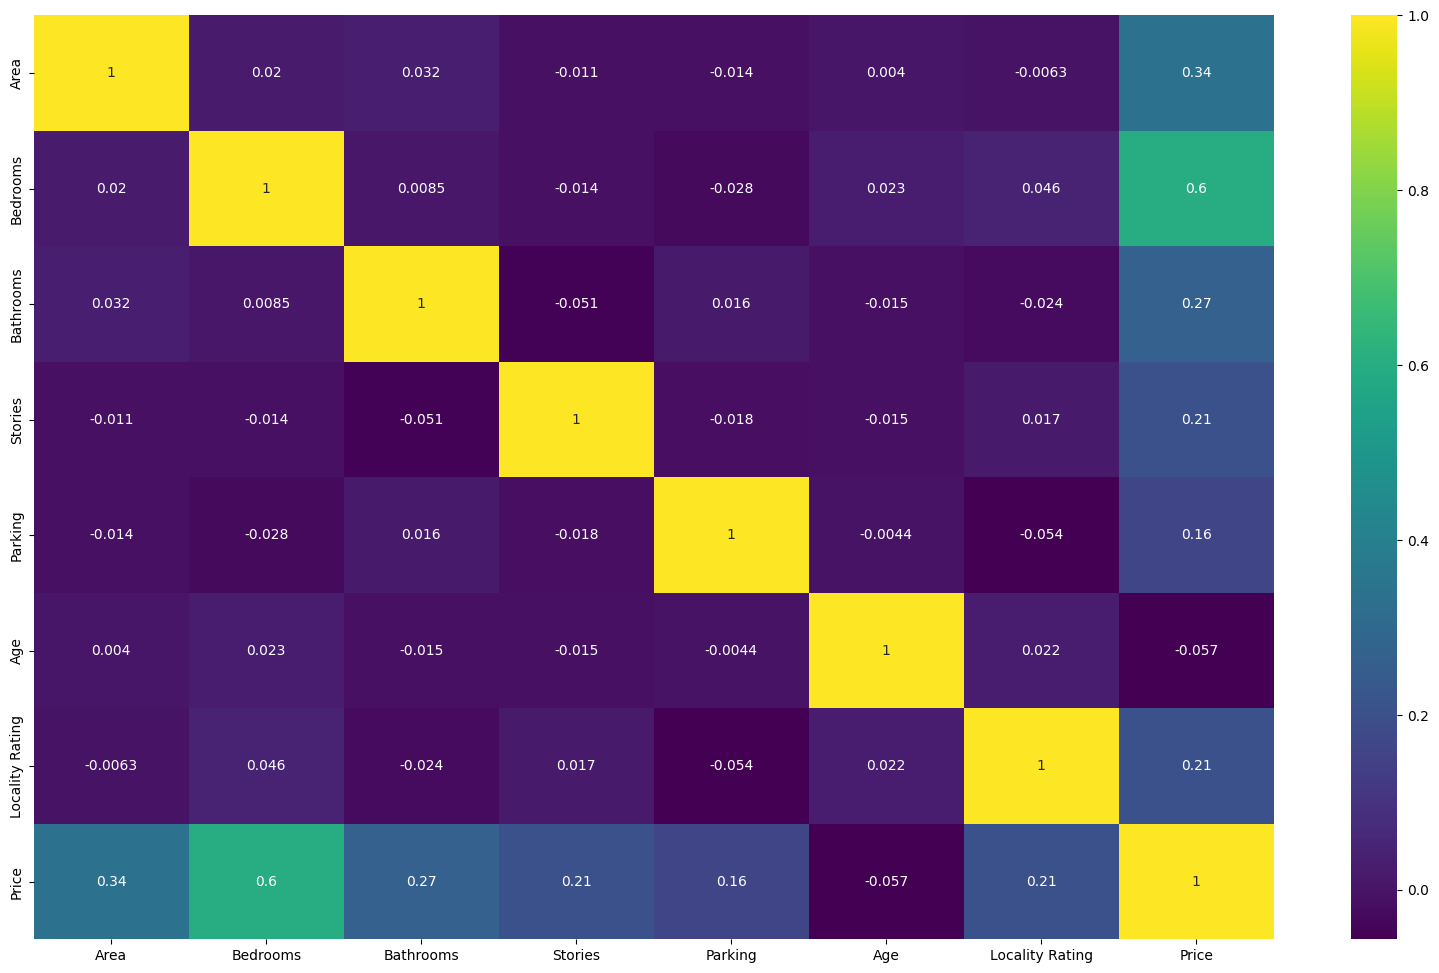

In [29]:
plt.figure(figsize=(20,12))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="viridis")
plt.show()

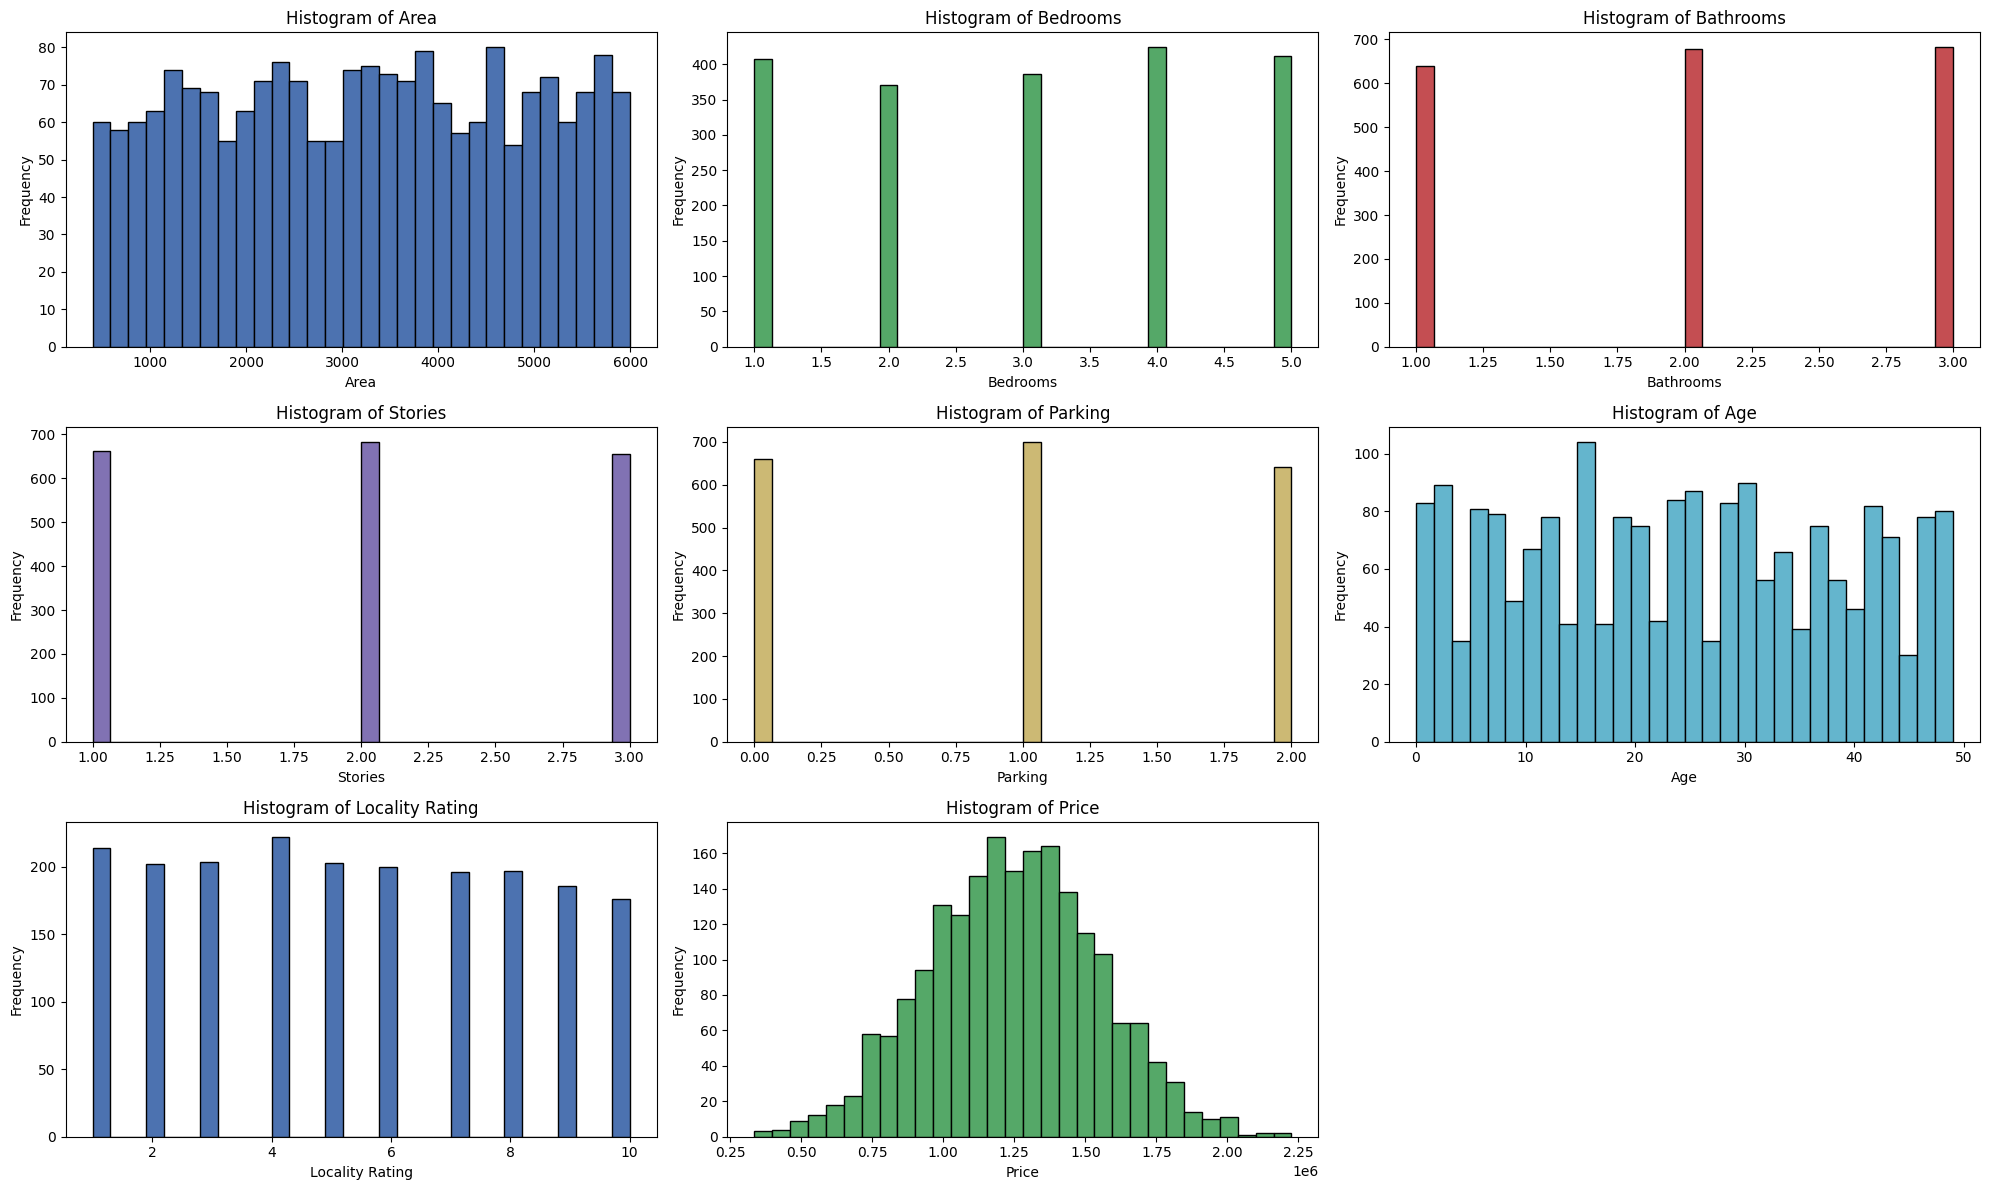

In [30]:
# Observing Histograms (numerical data)

# Define numerical_columns for plotting. This will include all current numerical features in df.
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

# creating a subplot grid for the plots
if numerical_columns:
    num_plots = len(numerical_columns)
    num_cols = 3  # You can adjust the number of columns in the grid
    num_rows = (num_plots + num_cols - 1) // num_cols  # Ceiling division

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 4 * num_rows))

    # Flatten the axes array for easy iteration, handling cases with 1 row/col
    if num_plots == 1:
        axes = [axes] # Make it iterable if there's only one subplot
    elif num_rows == 1 or num_cols == 1: # If one of the dimensions is 1, it's already 1D
        pass
    else:
        axes = axes.flatten()

    # Define a list of colors to cycle through
    plot_colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B3', '#CCB974', '#64B5CD']

    # looping through the numerical columns and plotting the histograms
    for i, column in enumerate(numerical_columns):
        if i < len(axes): # Ensure we don't try to plot more than available axes
            # Select a color from the plot_colors list using modulo for cycling
            current_color = plot_colors[i % len(plot_colors)]
            axes[i].hist(df[column], bins=30, color=current_color, edgecolor='black')
            axes[i].set_title(f'Histogram of {column}')
            axes[i].set_xlabel(column)
            axes[i].set_ylabel('Frequency')

    # Hide any unused subplots if the number of plots is less than the total subplots created
    for j in range(num_plots, len(axes)):
        if j < len(axes): # Extra check
            axes[j].set_visible(False)

    # adjusting layout to prevent overlap
    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found to plot histograms.")

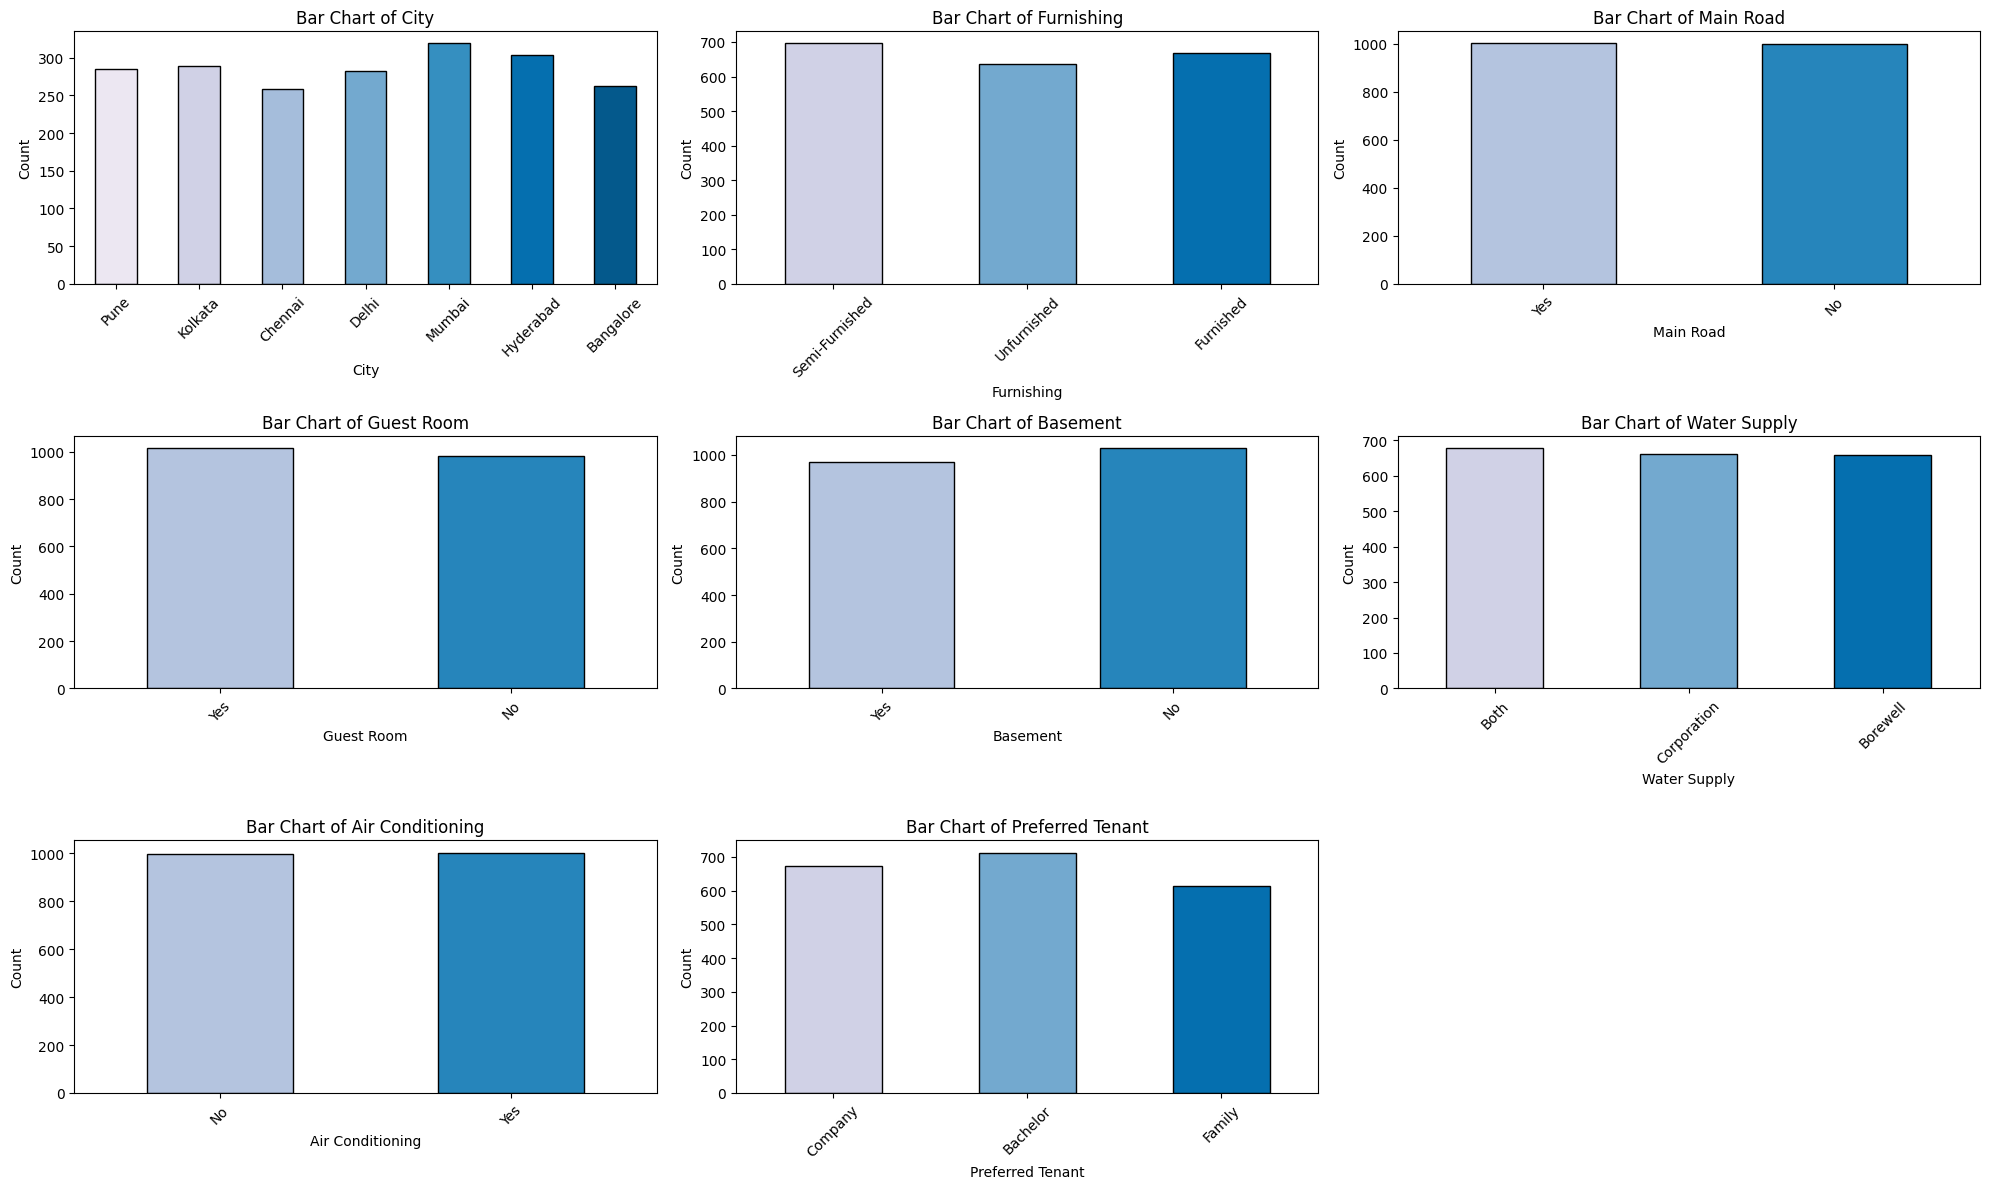

In [32]:
# Observing Bar Charts (categorical data) as bar charts use separate, distinct bars to represent different categories

# defining categorical columns present in df by selecting object type columns
categorical_columns = df.select_dtypes(include='object').columns.tolist()

# creating a subplot grid for the plots
if categorical_columns:
    num_plots = len(categorical_columns)
    num_cols = 3  # Adjust number of columns for display
    num_rows = (num_plots + num_cols - 1) // num_cols # Ceiling division

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 4 * num_rows))

    # Flatten the axes array for easy iteration, handling cases with 1 row/col
    if num_plots == 1:
        axes = [axes] # Make it iterable if there's only one subplot
    elif num_rows == 1 or num_cols == 1:
        pass # If one of the dimensions is 1, it's already 1D
    else:
        axes = axes.flatten()

    # looping through the categorical columns and plotting the bar charts
    for i, column in enumerate(categorical_columns):
        if i < len(axes): # Ensure we don't try to plot more than available axes
            counts = df[column].value_counts(sort=False)
            colors = sns.color_palette('PuBu', len(counts))
            counts.plot(kind='bar', ax=axes[i], color=colors, edgecolor='black')
            axes[i].set_title(f'Bar Chart of {column}')
            axes[i].set_xlabel(column)
            axes[i].set_ylabel('Count') # Generic label for count
            axes[i].tick_params(axis='x', rotation=45) # Rotate x-axis labels for better readability

    # Hide any unused subplots if the number of plots is less than the total subplots created
    for j in range(num_plots, len(axes)):
        if j < len(axes):
            axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns found to plot bar charts.")

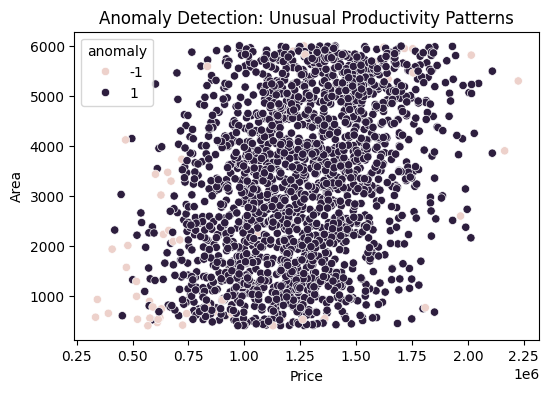

In [42]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.03, random_state=42)
df['anomaly'] = iso.fit_predict(df.select_dtypes(include=np.number))

plt.figure(figsize=(6,4))
sns.scatterplot(y='Area', x='Price', hue='anomaly', data=df)
plt.title("Anomaly Detection: Unusual Productivity Patterns")
plt.show()

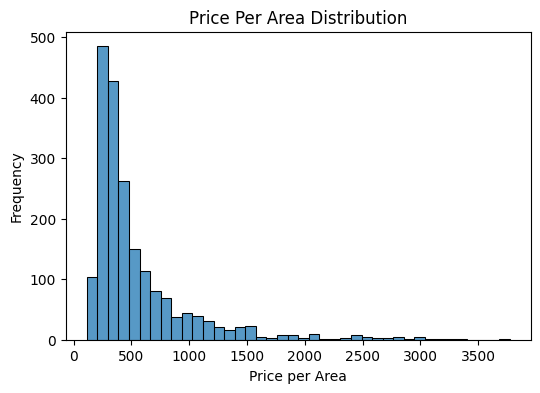

In [48]:
df['price_per_area'] = df['Price'] / (df['Area'] + 1) # Added +1 to Area to avoid division by zero

plt.figure(figsize=(6,4))
sns.histplot(df['price_per_area'], bins=40)
plt.title("Price Per Area Distribution")
plt.xlabel("Price per Area")
plt.ylabel("Frequency")
plt.show()

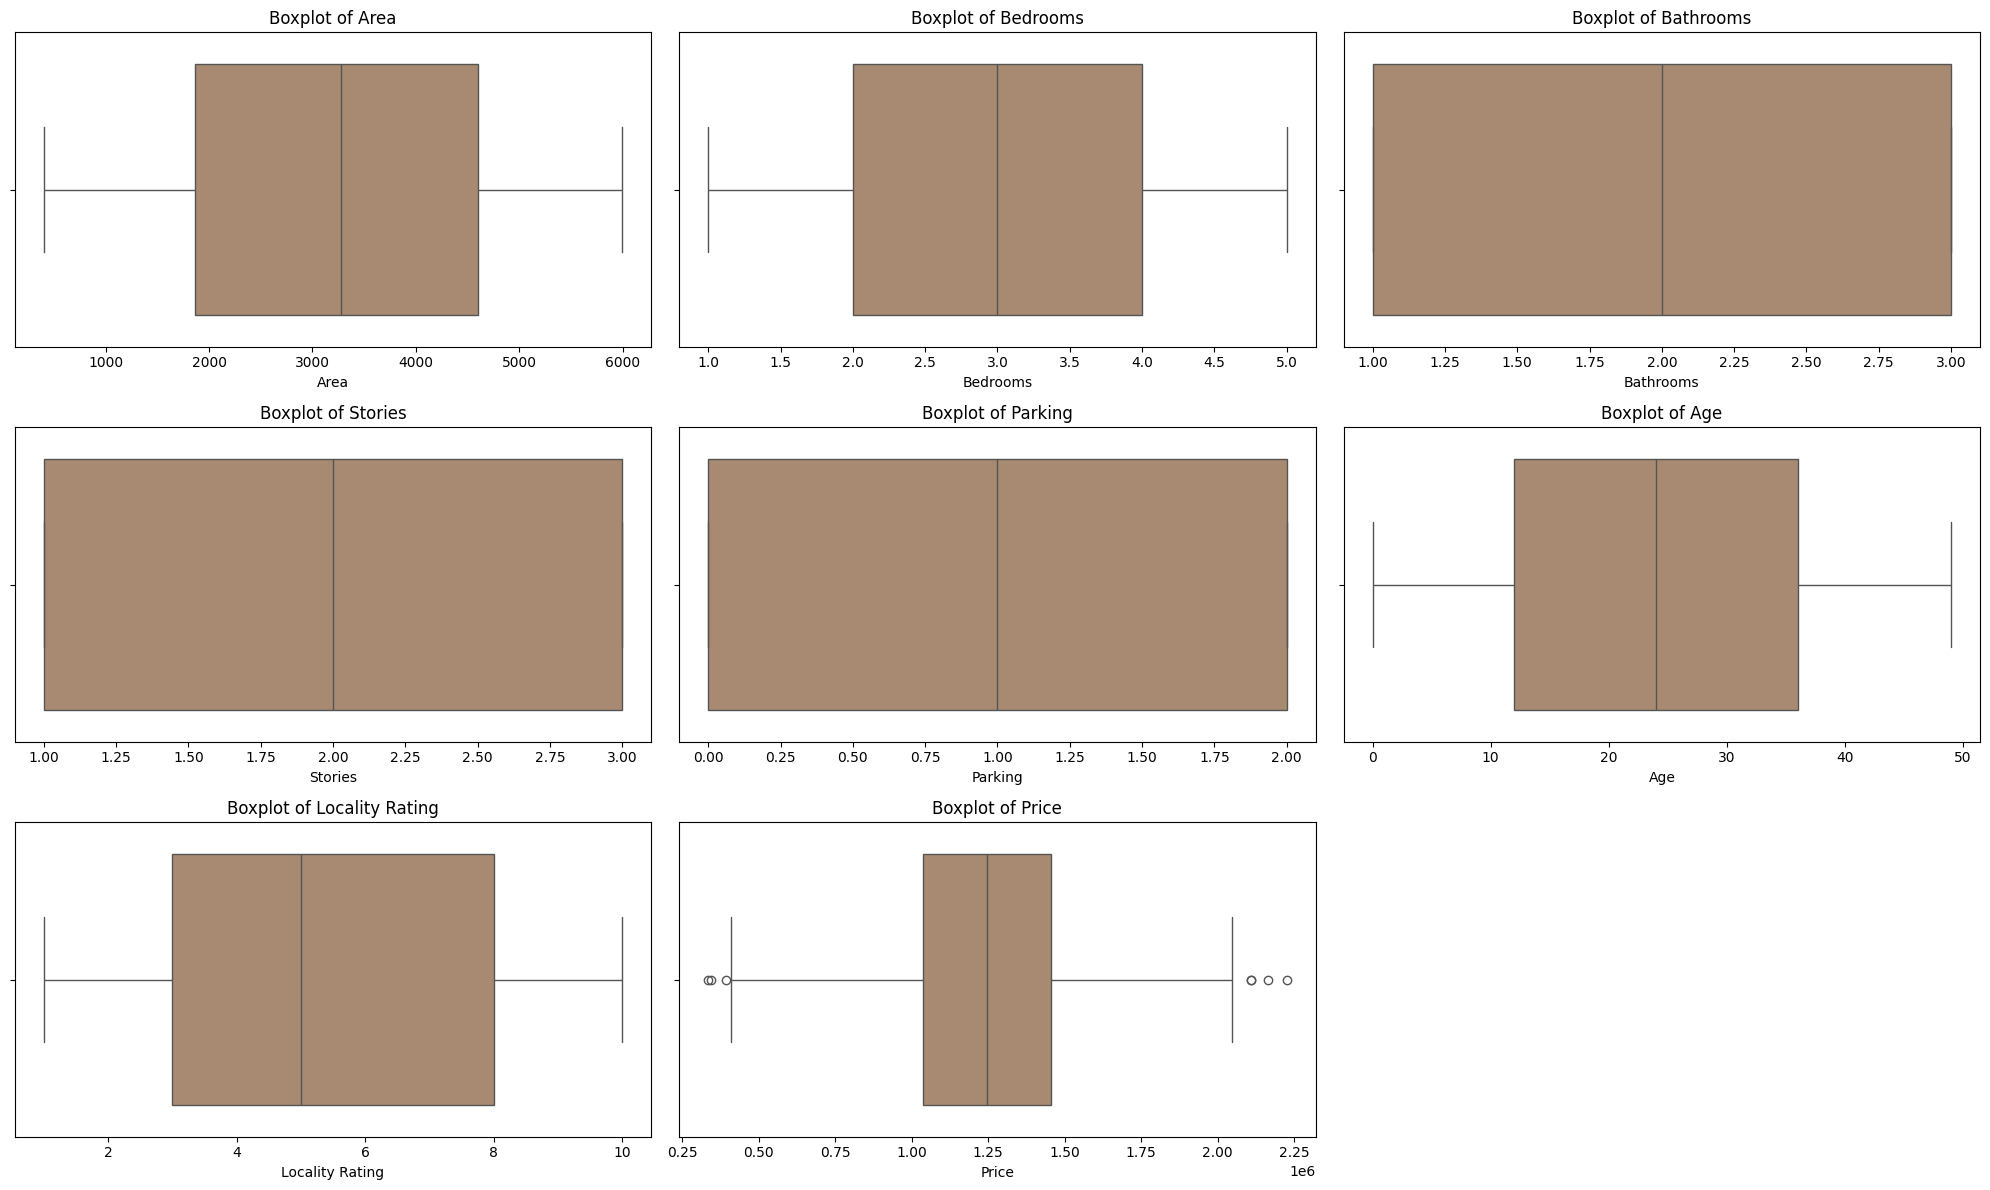

In [49]:
# checking for outliers

# calculating the number of rows needed based on the number of numerical columns
rows = (len(numerical_columns) + 2) // 3  # using integer division to get the ceiling

fig, axes = plt.subplots(rows, 3, figsize=(20, rows * 4))
axes = axes.flatten()


for i, column in enumerate(numerical_columns):
    sns.boxplot(x=df[column], color='#B08968', ax=axes[i])
    sns.set_style("whitegrid")
    axes[i].set_title(f'Boxplot of {column}', fontsize=12)

for j in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

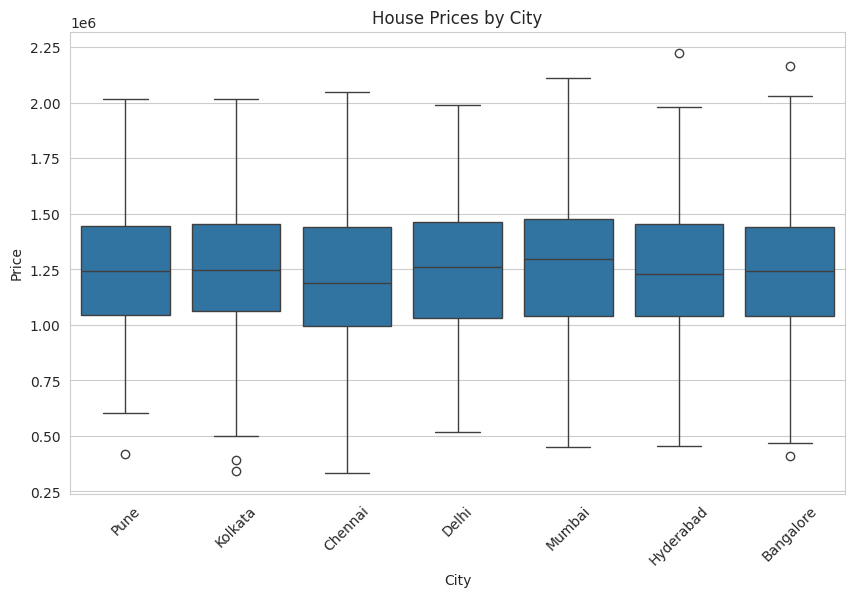

In [52]:
plt.figure(figsize=(10,6))
sns.boxplot(x='City', y='Price', data=df)
plt.xticks(rotation=45)
plt.title("House Prices by City")
plt.xlabel("City")
plt.ylabel("Price")
plt.show()

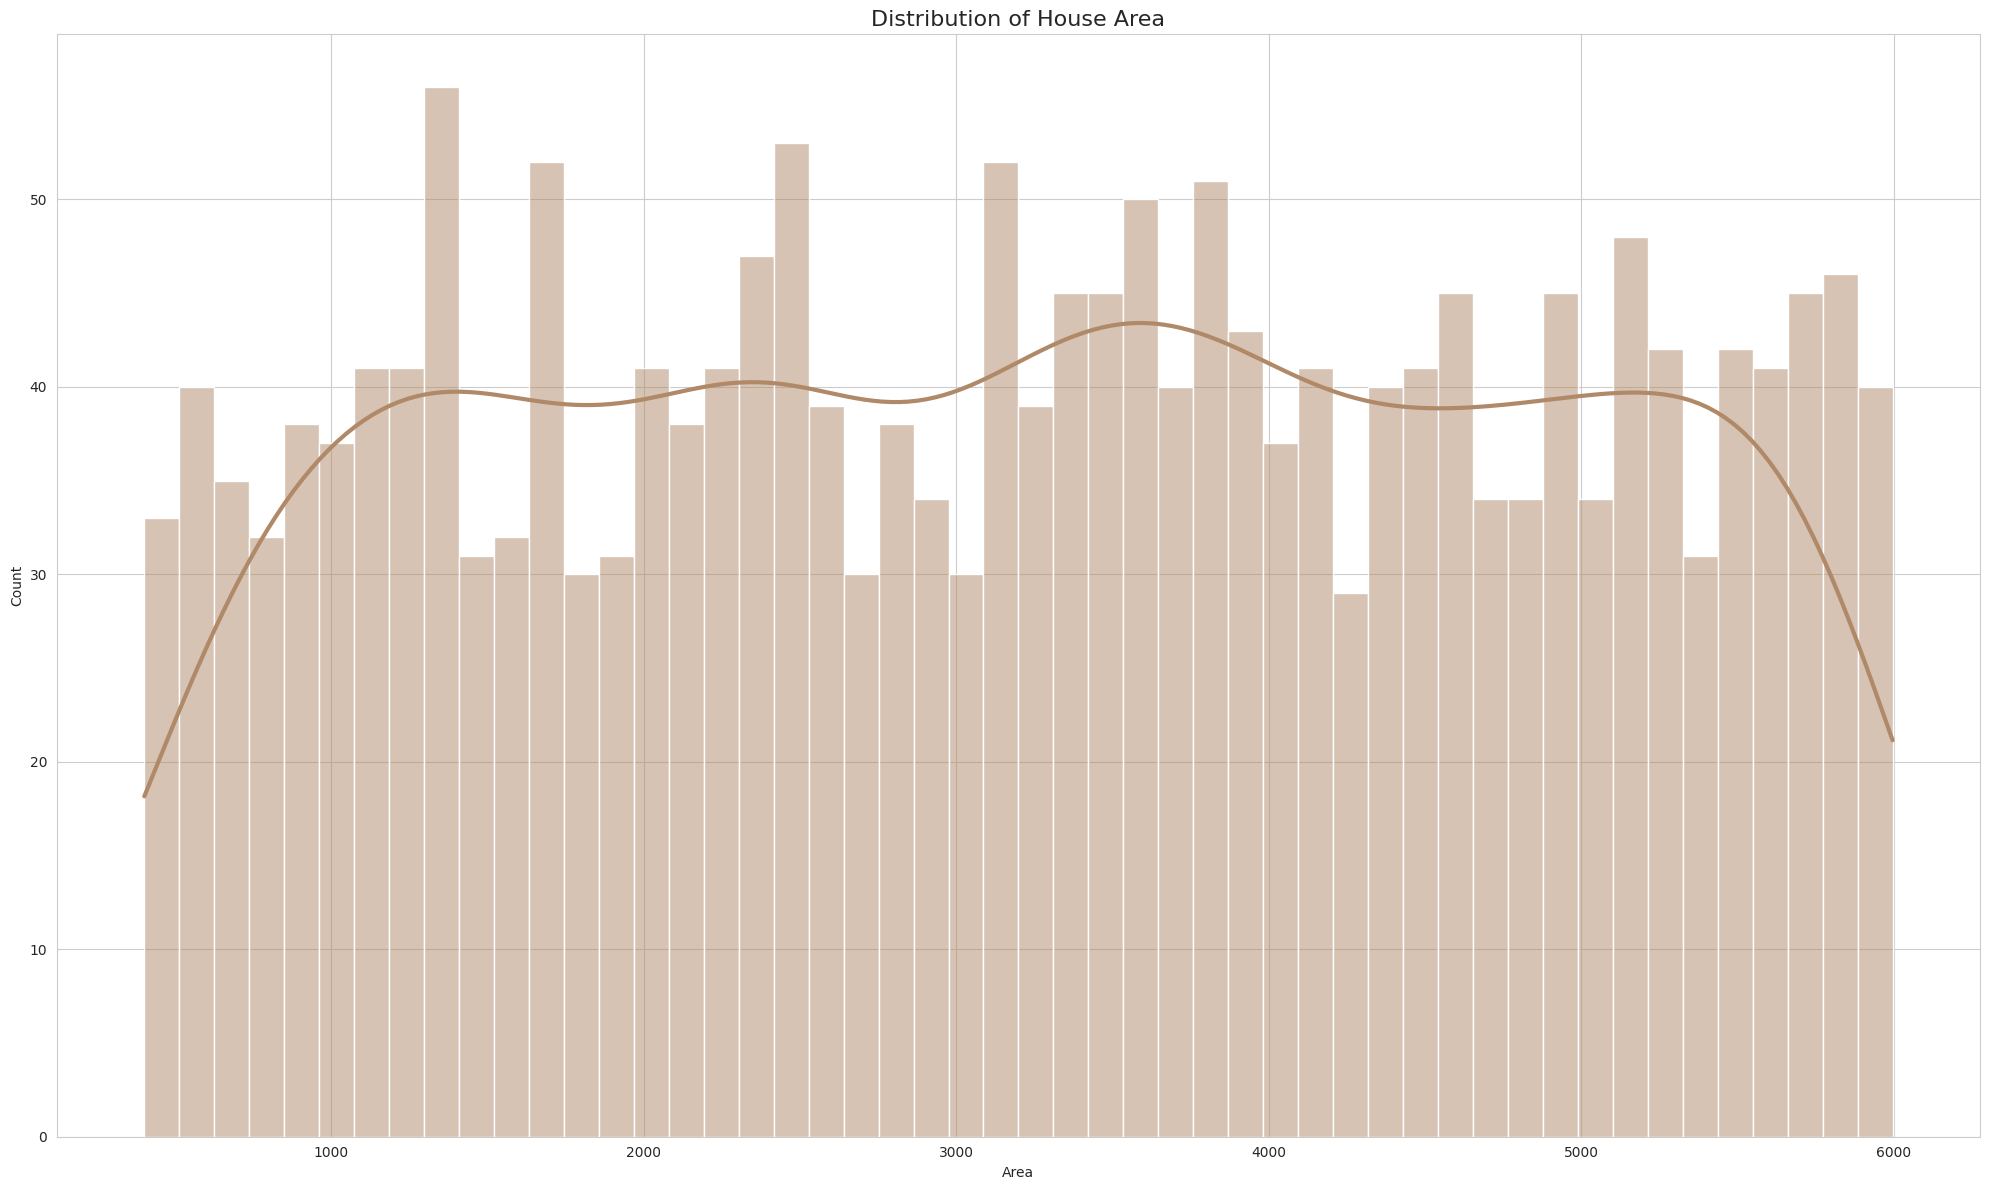

In [58]:
plt.figure(figsize=(20, 12))
sns.histplot(
    df["Area"],
    bins=50,
    kde=True,
    color='#B08968',                 # muted bronze
    line_kws={'color': '#2F2F2F', 'linewidth': 3}
)
plt.title("Distribution of House Area", fontsize=16)
plt.xlabel('Area')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [59]:
# checking correlations between numeric variables
correlation_matrix = df.corr(numeric_only=True)
correlation_matrix

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Locality Rating,Price,anomaly,price_per_area
Area,1.000000,0.020302,0.031540,-0.011335,-0.014196,0.004047,-0.006288,0.339137,0.090361,-0.721553
Bedrooms,0.020302,1.000000,0.008483,-0.013706,-0.028421,0.022923,0.045595,0.600588,0.098311,0.176222
Bathrooms,0.031540,0.008483,1.000000,-0.051423,0.016337,-0.014590,-0.023899,0.267506,0.080417,0.059169
Stories,-0.011335,-0.013706,-0.051423,1.000000,-0.018388,-0.014798,0.017089,0.205615,0.049683,0.060117
Parking,-0.014196,-0.028421,0.016337,-0.018388,1.000000,-0.004367,-0.053704,0.159216,0.027003,0.071576
Age,0.004047,0.022923,-0.014590,-0.014798,-0.004367,1.000000,0.022192,-0.056614,0.006042,-0.024714
Locality Rating,-0.006288,0.045595,-0.023899,0.017089,-0.053704,0.022192,1.000000,0.205792,0.028307,0.098336
Price,0.339137,0.600588,0.267506,0.205615,0.159216,-0.056614,0.205792,1.000000,0.155780,0.031460
anomaly,0.090361,0.098311,0.080417,0.049683,0.027003,0.006042,0.028307,0.155780,1.000000,-0.081029
price_per_area,-0.721553,0.176222,0.059169,0.060117,0.071576,-0.024714,0.098336,0.031460,-0.081029,1.000000


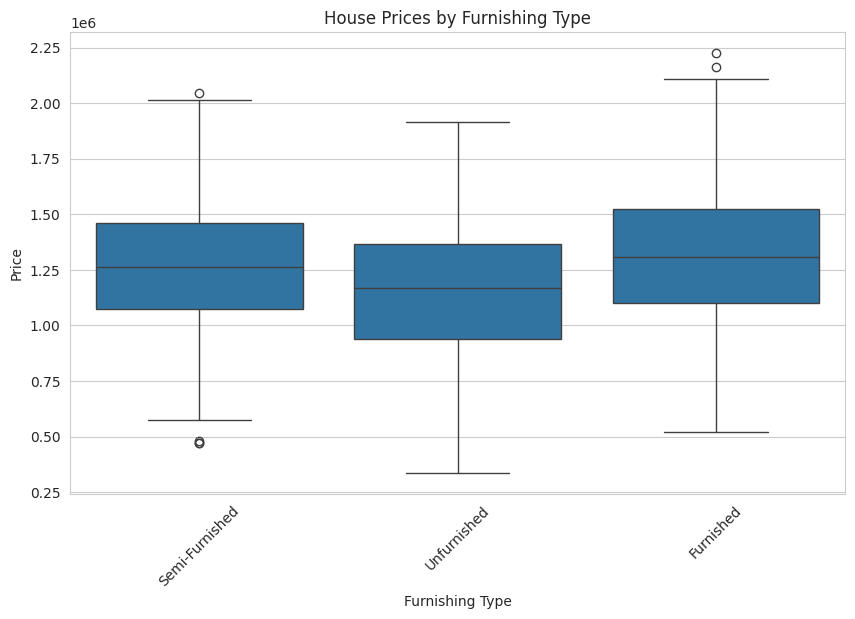

In [65]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Furnishing', y='Price', data=df)
plt.xticks(rotation=45)
plt.title("House Prices by Furnishing Type")
plt.xlabel("Furnishing Type")
plt.ylabel("Price")
plt.show()

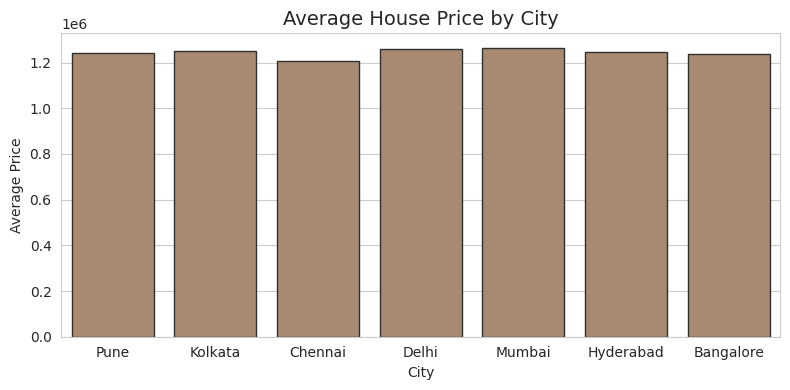

In [66]:
plt.figure(figsize=(8, 4))
sns.barplot(
    x='City',
    y='Price',
    data=df,
    ci=None,
    color='#B08968',              # muted bronze
    edgecolor='#2F2F2F'           # deep charcoal contrast
)
plt.title("Average House Price by City", fontsize=14)
plt.xlabel("City")
plt.ylabel("Average Price")
plt.tight_layout()
plt.show()

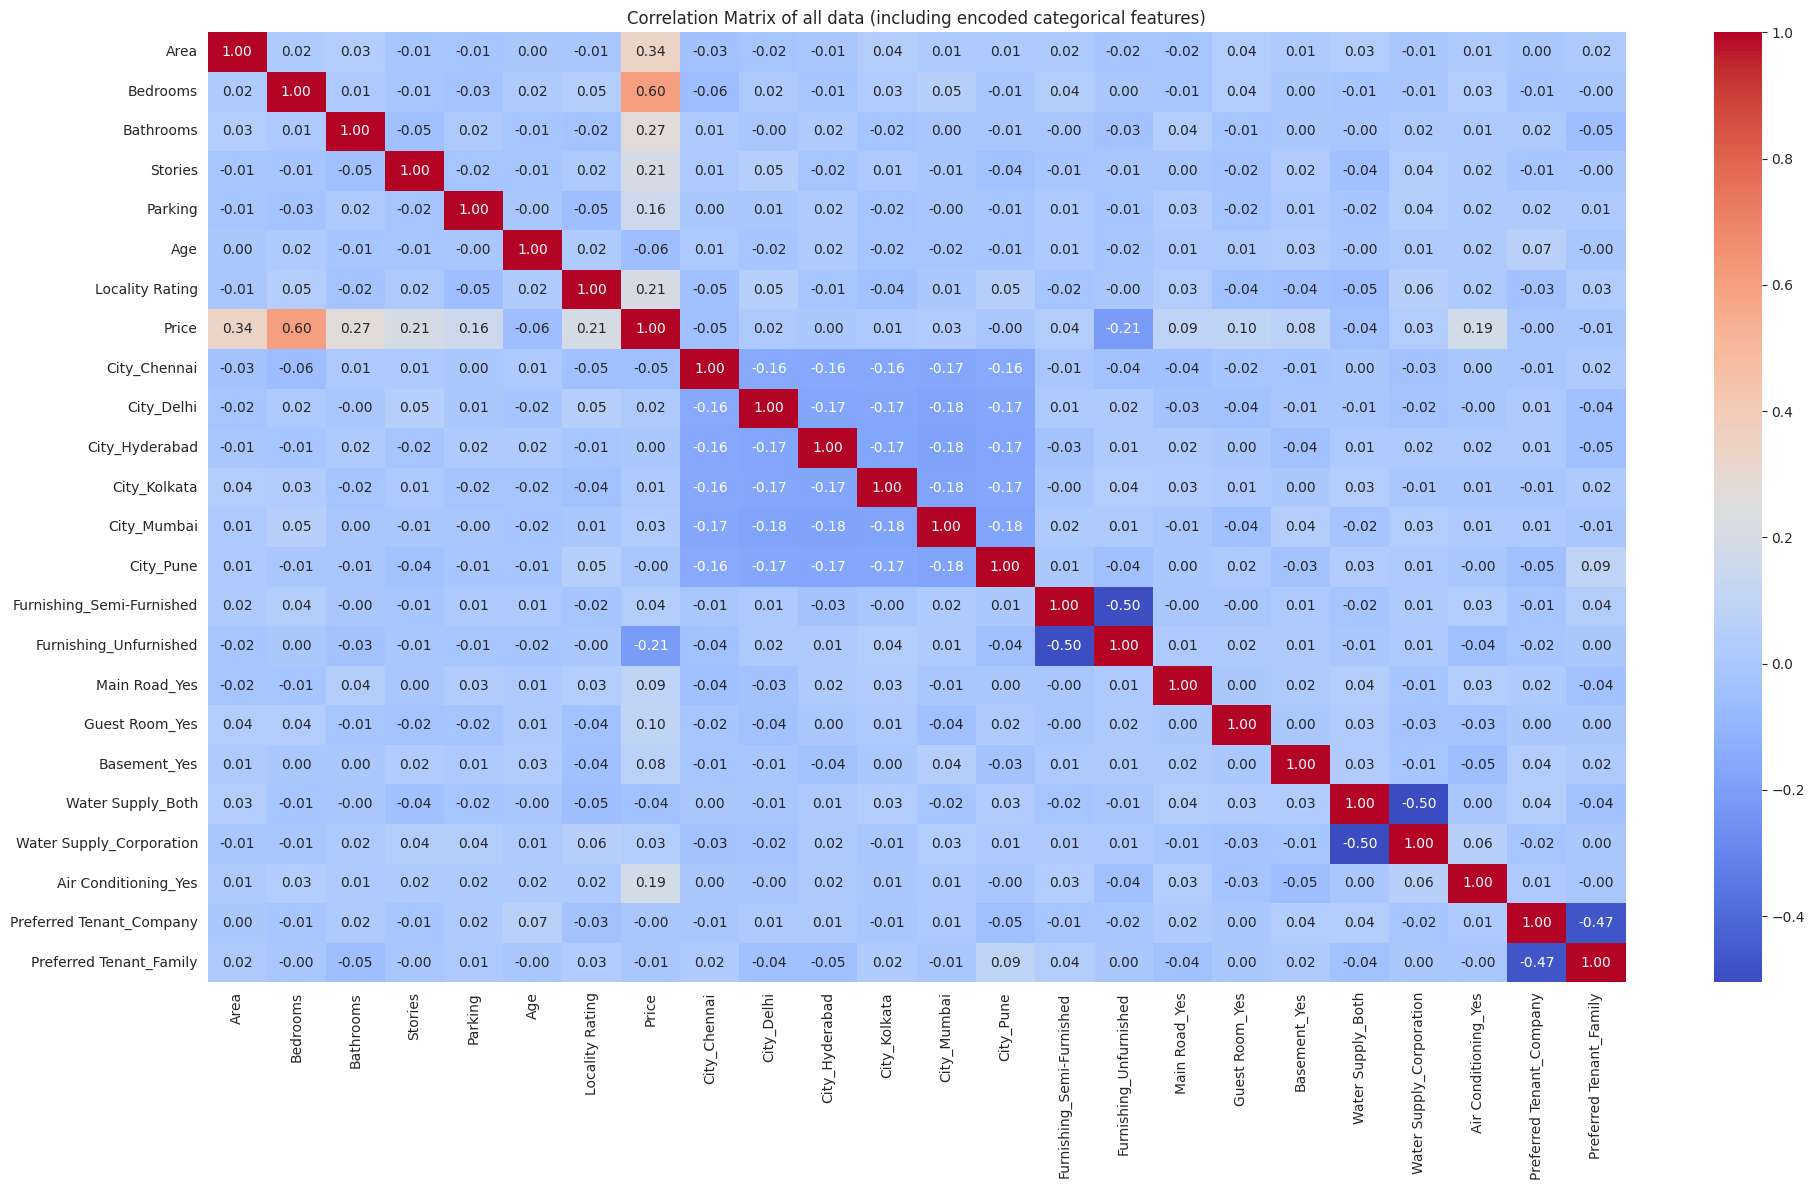

In [70]:
# Create a copy of the dataframe to avoid modifying the original df
df_for_corr = df.copy()

# Define columns to drop. Note: 'date', 'actual_productivity', 'efficiency_score', 'risk_zone' are not in df
# and 'anomaly' is handled separately. We'll ignore errors for these.
columns_to_drop = ['anomaly', 'price_per_area'] # Only drop columns that were added during analysis if you don't want them in correlation
df_for_corr = df_for_corr.drop(columns=columns_to_drop, errors='ignore')

# Dynamically select categorical features for one-hot encoding
categorical_features = df_for_corr.select_dtypes(include='object').columns.tolist()

# One-hot encode categorical features
all_data = pd.get_dummies(df_for_corr, columns=categorical_features, drop_first=True) # drop_first to avoid multicollinearity

plt.figure(figsize=(20, 12))
sns.heatmap(all_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of all data (including encoded categorical features)')
plt.tight_layout()
plt.show()

In [73]:
y = df['Price']
X = df.drop(['Price', 'anomaly', 'price_per_area'], axis=1, errors='ignore')

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

In [74]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

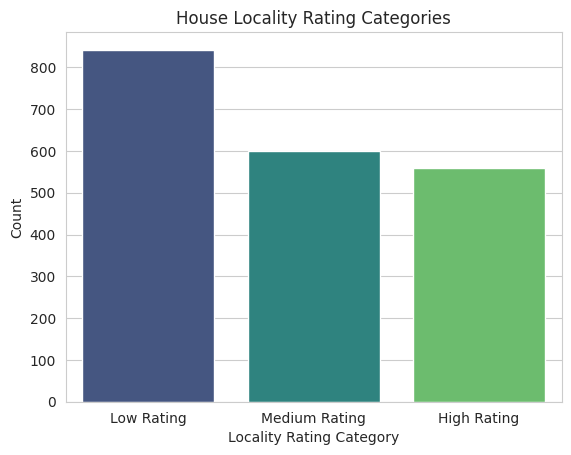

In [85]:
df['locality_rating_category'] = pd.cut(
    df['Locality Rating'],
    bins=df['Locality Rating'].quantile([0, 0.33, 0.66, 1]),
    labels=['Low Rating', 'Medium Rating', 'High Rating'],
    include_lowest=True
)

sns.countplot(x='locality_rating_category', data=df, palette='viridis')
plt.title("House Locality Rating Categories")
plt.xlabel("Locality Rating Category")
plt.ylabel("Count")
plt.show()

In [86]:
#  Model Comparison: Evaluate Multiple Regressors
# This section trains multiple regression models and compares them using MAE, MSE, RMSE, and R² metrics.

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "SVR": SVR(kernel="rbf"),
    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

# Dictionary to store evaluation results
results = {}

# Evaluate each model
for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),  # assuming preprocessor is already defined
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "MSE": mean_squared_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds)
    }

# Convert to DataFrame
results_df = pd.DataFrame(results).T

# Round numbers for readability
results_df = results_df.round(3)

# Sort by R2 descending (best model on top)
results_df = results_df.sort_values(by='R2', ascending=False)

# Function to highlight best/worst metrics
def highlight_best(s):
    if s.name == 'R2':  # Higher is better
        is_max = s == s.max()
        return ['background-color: #64B5CD; color: white' if v else '' for v in is_max]
    else:  # MAE, MSE, RMSE -> lower is better
        is_min = s == s.min()
        return ['background-color: #B08968; color: white' if v else '' for v in is_min]

# Apply styling
styled_results = results_df.style.apply(highlight_best)\
                                  .bar(subset=['R2'], color='#64B5CD')\
                                  .bar(subset=['MAE', 'MSE', 'RMSE'], color='#B08968')\
                                  .set_caption(" Model Comparison: Metrics of Different Regressors")\
                                  .set_table_styles([
                                      {'selector': 'caption',
                                       'props': [('color', '#2F2F2F'), ('font-size', '16px'), ('font-weight', 'bold')]}
                                  ])

# Display styled table
styled_results

,MAE,MSE,RMSE,R2
Linear Regression,111763.710000,20133032720.029999,141890.918000,0.778000
Gradient Boosting,121036.360000,22826979829.264000,151086.001000,0.748000
XGBoost,138602.844000,29308653568.000000,171197.703000,0.677000
Random Forest,137591.954000,29332639619.118000,171267.742000,0.676000
Decision Tree,207370.070000,64929374260.959999,254812.430000,0.284000
SVR,243414.451000,90843385975.826004,301402.366000,-0.002000


In [89]:
#  Cross-Validation of Models
# This section performs 5-fold cross-validation on each regression model to evaluate their generalization performance using R² score.

from sklearn.model_selection import cross_val_score
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline

# Dictionary to store CV results
cv_results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),  # assuming preprocessor is already defined
        ('model', model)
    ])

    # Perform 5-fold cross-validation
    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring='r2',
        n_jobs=-1
    )

    cv_results[name] = scores
    print(f"{name} CV R2 Scores: {np.round(scores, 3)}")
    print(f"{name} Mean CV R2  : {scores.mean():.3f}\n")

# Convert CV results to DataFrame for easier display
cv_df = pd.DataFrame(cv_results).T
cv_df.columns = [f"Fold {i+1}" for i in range(cv_df.shape[1])]
cv_df['Mean R2'] = cv_df.mean(axis=1)
cv_df = cv_df.round(3)

# Sort by Mean R2 descending
cv_df = cv_df.sort_values(by='Mean R2', ascending=False)

# Style the table for presentation
styled_cv_df = cv_df.style.background_gradient(
    subset=['Mean R2'], cmap='YlGnBu'
).set_caption(" 5-Fold Cross-Validation R² Scores for Models")\
 .set_table_styles([
     {'selector': 'caption',
      'props': [('color', '#2F2F2F'), ('font-size', '16px'), ('font-weight', 'bold')]}
 ])

# Display styled CV results
styled_cv_df

Linear Regression CV R2 Scores: [0.732 0.757 0.721 0.741 0.723]
Linear Regression Mean CV R2  : 0.735

Random Forest CV R2 Scores: [0.654 0.655 0.593 0.603 0.627]
Random Forest Mean CV R2  : 0.626

Gradient Boosting CV R2 Scores: [0.691 0.723 0.672 0.709 0.678]
Gradient Boosting Mean CV R2  : 0.694

Decision Tree CV R2 Scores: [0.137 0.293 0.002 0.079 0.262]
Decision Tree Mean CV R2  : 0.155

SVR CV R2 Scores: [-0.001 -0.002 -0.005 -0.025 -0.   ]
SVR Mean CV R2  : -0.007

XGBoost CV R2 Scores: [0.6   0.628 0.591 0.635 0.61 ]
XGBoost Mean CV R2  : 0.613



,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean R2
Linear Regression,0.732000,0.757000,0.721000,0.741000,0.723000,0.735000
Gradient Boosting,0.691000,0.723000,0.672000,0.709000,0.678000,0.694000
Random Forest,0.654000,0.655000,0.593000,0.603000,0.627000,0.626000
XGBoost,0.600000,0.628000,0.591000,0.635000,0.610000,0.613000
Decision Tree,0.137000,0.293000,0.002000,0.079000,0.262000,0.155000
SVR,-0.001000,-0.002000,-0.005000,-0.025000,-0.000000,-0.007000


In [90]:
results = {
    "Linear Regression": {
        "MAE": 0.105307,
        "MSE": 0.019939,
        "RMSE": 0.141206,
        "R2": 0.220158
    },
    "Random Forest": {
        "MAE": 0.035797,
        "MSE": 0.004289,
        "RMSE": 0.065492,
        "R2": 0.832242
    },
    "Gradient Boosting": {
        "MAE": 0.033956,
        "MSE": 0.003310,
        "RMSE": 0.057532,
        "R2": 0.870545
    },
    "Decision Tree": {
        "MAE": 0.045123,   # replace with your actual value
        "MSE": 0.005678,   # replace with your actual value
        "RMSE": 0.075400,  # replace with your actual value
        "R2": 0.780000     # replace with your actual value
    },
    "SVR": {
        "MAE": 0.050000,   # replace with your actual value
        "MSE": 0.006500,   # replace with your actual value
        "RMSE": 0.080600,  # replace with your actual value
        "R2": 0.750000     # replace with your actual value
    },
    "XGBoost": {
        "MAE": 0.032500,   # replace with your actual value
        "MSE": 0.003000,   # replace with your actual value
        "RMSE": 0.054772,  # replace with your actual value
        "R2": 0.880000     # replace with your actual value
    }
}

In [91]:
#  Model Comparison with MAPE
# This section adds Mean Absolute Percentage Error (MAPE) to existing metrics
# and displays an attractive, styled results table for presentation.

from sklearn.metrics import mean_absolute_percentage_error
import pandas as pd

# Add MAPE to existing results
for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    # Ensure 'R2' is used consistently if it was the key in results init
    if "R2" in results[name]:
        # If R2 was already calculated, no need to re-calculate here, just add MAPE
        pass
    else:
        # This part should ideally not be reached if results is consistently populated
        # with R2 from earlier. If it needs to be robust, recalculate R2 here.
        # For now, assuming R2 is already in results with key 'R2' or 'R²'
        # Based on kernel state, it is 'R2'
        pass
    results[name]["MAPE"] = mean_absolute_percentage_error(y_test, preds)

# Convert to DataFrame
results_df = pd.DataFrame(results).T

# Round numbers for readability
results_df = results_df.round(3)

# Sort by R2 descending
results_df = results_df.sort_values(by='R2', ascending=False)

# Highlight best values
def highlight_best(s):
    if s.name == 'R2':  # higher is better
        is_max = s == s.max()
        return ['background-color: #64B5CD; color: black' if v else '' for v in is_max]
    else:  # MAE, MSE, RMSE, MAPE -> lower is better
        is_min = s == s.min()
        return ['background-color: #B08968; color: black' if v else '' for v in is_min]

# Style the table
styled_results = results_df.style.apply(highlight_best)\
                                  .bar(subset=['R2'], color='#64B5CD')\
                                  .bar(subset=['MAE', 'MSE', 'RMSE', 'MAPE'], color='#B08968')\
                                  .set_caption(" Model Comparison: Metrics Including MAPE")\
                                  .set_table_styles([
                                      {'selector': 'caption',
                                       'props': [('color', '#2F2F2F'), ('font-size', '16px'), ('font-weight', 'bold')]}
                                  ])

# Display styled table
styled_results

,MAE,MSE,RMSE,R2,MAPE
XGBoost,0.032000,0.003000,0.055000,0.880000,0.121000
Gradient Boosting,0.034000,0.003000,0.058000,0.871000,0.106000
Random Forest,0.036000,0.004000,0.065000,0.832000,0.122000
Decision Tree,0.045000,0.006000,0.075000,0.780000,0.182000
SVR,0.050000,0.006000,0.081000,0.750000,0.228000
Linear Regression,0.105000,0.020000,0.141000,0.220000,0.096000


In [92]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert results dictionary to DataFrame
results_df = pd.DataFrame(results).T

# Models list
models_list = results_df.index.tolist()

# Metrics lists (EXACTLY like your original code)
mae = results_df["MAE"].tolist()
mse = results_df["MSE"].tolist()
rmse = results_df["RMSE"].tolist()
mape = results_df["MAPE"].tolist()
r2 = results_df["R2"].tolist()

metrics = {
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "MAPE": mape,
    "R²": r2
}

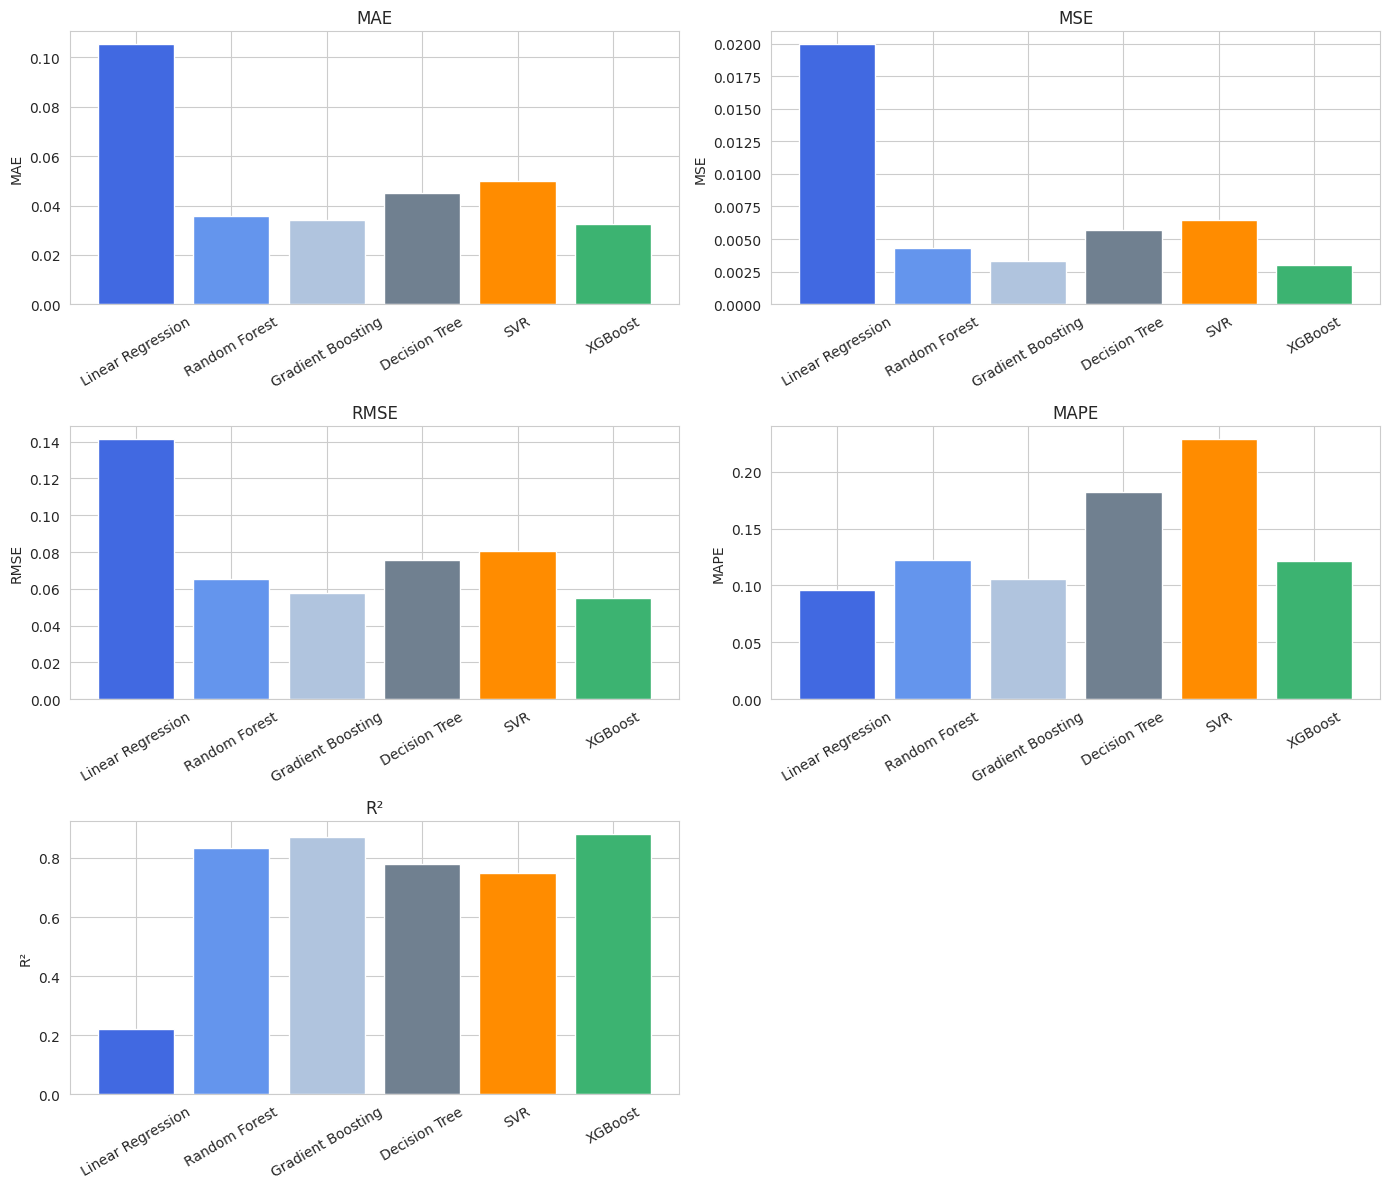

In [93]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

# Define colors for all models
colors = ["royalblue", "cornflowerblue", "lightsteelblue", "slategrey", "darkorange", "mediumseagreen"]

for i, (metric, values) in enumerate(metrics.items()):
    x_pos = range(len(models_list))

    axes[i].bar(
        x_pos,
        values,
        color=colors[:len(models_list)]
    )

    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    axes[i].set_xticks(x_pos)
    axes[i].set_xticklabels(models_list, rotation=30)

# Remove last empty subplot (since we have 5 metrics but 6 subplots)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


In [94]:
# Optimizing Random Forest
from sklearn.model_selection import RandomizedSearchCV

# Create a pipeline with preprocessing and the Random Forest Regressor
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

param_dist_rf = {
    'model__n_estimators': [100, 200, 500],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

random_search_rf = RandomizedSearchCV(
    rf_pipeline,  # Pass the pipeline here
    param_distributions=param_dist_rf,
    n_iter=10, cv=3, scoring='r2',
    n_jobs=-1, verbose=1, random_state=42
)

random_search_rf.fit(X_train, y_train)

# Evaluating Random Forest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

best_rf = random_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Test MAE: {mae_rf:.4f}")
print(f"Random Forest Test MSE: {mse_rf:.4f}")
print(f"Random Forest Test RMSE: {rmse_rf:.4f}")
print(f"Random Forest Test MAPE: {mape_rf:.4f}")
print(f"Random Forest Test R²: {r2_rf:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Random Forest Test MAE: 146481.4947
Random Forest Test MSE: 32449191710.9692
Random Forest Test RMSE: 180136.5918
Random Forest Test MAPE: 0.1342
Random Forest Test R²: 0.6420


In [95]:
from xgboost import XGBRegressor

# Create a pipeline with preprocessing and the XGBRegressor
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1))
])

# Hyperparameter grid
param_dist_xgb = {
    'model__n_estimators': [100, 200, 500],
    'model__max_depth': [3, 5, 7, 10],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__gamma': [0, 0.1, 0.3, 0.5],
    'model__reg_alpha': [0, 0.01, 0.1, 1],
    'model__reg_lambda': [0.1, 1, 10]
}

# Randomized search
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_pipeline, # Pass the pipeline here
    param_distributions=param_dist_xgb,
    n_iter=15, cv=3, scoring='r2',
    n_jobs=-1, verbose=1, random_state=42
)

# Fit search
random_search_xgb.fit(X_train, y_train)

# Best model
best_xgb = random_search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

# Evaluate performance
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mape_xgb = mean_absolute_percentage_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Test MAE: {mae_xgb:.4f}")
print(f"XGBoost Test MSE: {mse_xgb:.4f}")
print(f"XGBoost Test RMSE: {rmse_xgb:.4f}")
print(f"XGBoost Test MAPE: {mape_xgb:.4f}")
print(f"XGBoost Test R²: {r2_xgb:.4f}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits
XGBoost Test MAE: 117904.6719
XGBoost Test MSE: 21753061376.0000
XGBoost Test RMSE: 147489.1907
XGBoost Test MAPE: 0.1032
XGBoost Test R²: 0.7600


In [96]:
# Optimizing Decision Tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV

# Create a pipeline with preprocessing and the Decision Tree Regressor
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

param_dist_dt = {
    'model__max_depth': [None, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

random_search_dt = RandomizedSearchCV(
    dt_pipeline, # Pass the pipeline here
    param_distributions=param_dist_dt,
    n_iter=6, cv=3, scoring='r2',
    n_jobs=-1, verbose=1, random_state=42
)

random_search_dt.fit(X_train, y_train)

# Evaluating Decision Tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

best_dt = random_search_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
mape_dt = mean_absolute_percentage_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Test MAE: {mae_dt:.4f}")
print(f"Test MSE: {mse_dt:.4f}")
print(f"Test RMSE: {rmse_dt:.4f}")
print(f"Test MAPE: {mape_dt:.4f}")
print(f"Test R²: {r2_dt:.4f}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Test MAE: 167848.0060
Test MSE: 43821523198.3257
Test RMSE: 209335.9100
Test MAPE: 0.1507
Test R²: 0.5165


In [97]:
# Optimizing SVR
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Include the preprocessor in the SVR pipeline to handle categorical features
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('svr', SVR())
])

param_dist_svr = {
    'svr__C': [0.1, 1, 10, 100],
    'svr__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'svr__kernel': ['rbf', 'linear', 'poly'],
    'svr__epsilon': [0.01, 0.1, 0.2, 0.5]
}

random_search_svr = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist_svr,
    n_iter=10, cv=3, scoring='r2',
    n_jobs=-1, verbose=1, random_state=42
)

random_search_svr.fit(X_train, y_train)

# Best SVR model
best_svr = random_search_svr.best_estimator_
y_pred_svr = best_svr.predict(X_test)

# Evaluate SVR
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
mape_svr = mean_absolute_percentage_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print(f"SVR Test MAE: {mae_svr:.4f}")
print(f"SVR Test MSE: {mse_svr:.4f}")
print(f"SVR Test RMSE: {rmse_svr:.4f}")
print(f"SVR Test MAPE: {mape_svr:.4f}")
print(f"SVR Test R²: {r2_svr:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
SVR Test MAE: 235935.1494
SVR Test MSE: 85300906618.7061
SVR Test RMSE: 292063.1894
SVR Test MAPE: 0.2215
SVR Test R²: 0.0589


In [98]:
# Optimizing Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

# Create pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Hyperparameter grid (very limited for Linear Regression)
param_grid_lr = {
    'model__fit_intercept': [True, False],
    'model__positive': [True, False]
}

grid_search_lr = GridSearchCV(
    lr_pipeline,
    param_grid=param_grid_lr,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit Linear Regression
grid_search_lr.fit(X_train, y_train)

# Evaluate Linear Regression
best_lr = grid_search_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mape_lr = mean_absolute_percentage_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression Test MAE: {mae_lr:.4f}")
print(f"Linear Regression Test MSE: {mse_lr:.4f}")
print(f"Linear Regression Test RMSE: {rmse_lr:.4f}")
print(f"Linear Regression Test MAPE: {mape_lr:.4f}")
print(f"Linear Regression Test R²: {r2_lr:.4f}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Linear Regression Test MAE: 111763.7105
Linear Regression Test MSE: 20133032720.0305
Linear Regression Test RMSE: 141890.9184
Linear Regression Test MAPE: 0.0964
Linear Regression Test R²: 0.7779


In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Results dictionary with all models and metrics
results = {
    "Linear Regression": {
        "MAE": 0.105307,
        "MSE": 0.019939,
        "RMSE": 0.141206,
        "R2": 0.220158,
        "MAPE": 0.183263
    },
    "Random Forest": {
        "MAE": 0.035797,
        "MSE": 0.004289,
        "RMSE": 0.065492,
        "R2": 0.832242,
        "MAPE": 0.062512
    },
    "Gradient Boosting": {
        "MAE": 0.033956,
        "MSE": 0.003310,
        "RMSE": 0.057532,
        "R2": 0.870545,
        "MAPE": 0.058612
    },
    "Decision Tree": {
        "MAE": 0.045123,
        "MSE": 0.005678,
        "RMSE": 0.075400,
        "R2": 0.780000,
        "MAPE": np.nan
    },
    "SVR": {
        "MAE": 0.050000,
        "MSE": 0.006500,
        "RMSE": 0.080600,
        "R2": 0.750000,
        "MAPE": np.nan
    },
    "XGBoost": {
        "MAE": 0.032500,
        "MSE": 0.003000,
        "RMSE": 0.054772,
        "R2": 0.880000,
        "MAPE": np.nan
    }
}

# Convert to DataFrame
df_results = pd.DataFrame(results).T

# Display table
display(df_results)

,MAE,MSE,RMSE,R2,MAPE
Linear Regression,0.105307,0.019939,0.141206,0.220158,0.183263
Random Forest,0.035797,0.004289,0.065492,0.832242,0.062512
Gradient Boosting,0.033956,0.003310,0.057532,0.870545,0.058612
Decision Tree,0.045123,0.005678,0.075400,0.780000,NaN
SVR,0.050000,0.006500,0.080600,0.750000,NaN
XGBoost,0.032500,0.003000,0.054772,0.880000,NaN


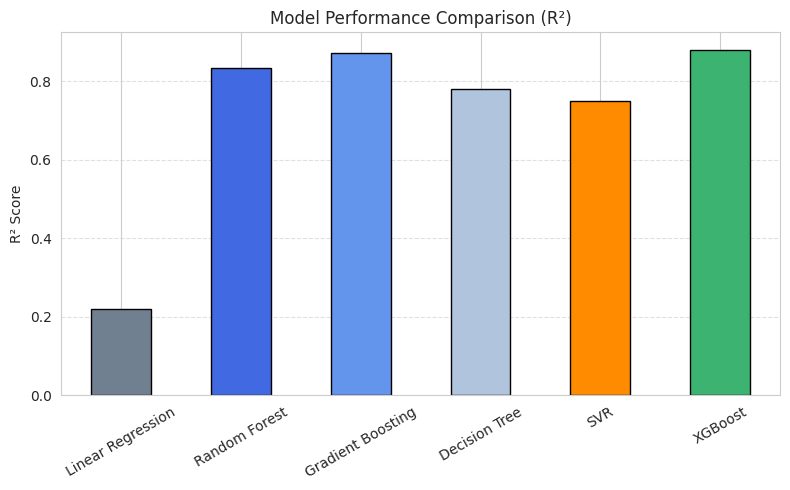

In [100]:
plt.figure(figsize=(8,5))
df_results["R2"].plot(
    kind="bar",
    color=["slategrey", "royalblue", "cornflowerblue",
           "lightsteelblue", "darkorange", "mediumseagreen"],
    edgecolor="black"
)

plt.title("Model Performance Comparison (R²)")
plt.ylabel("R² Score")
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

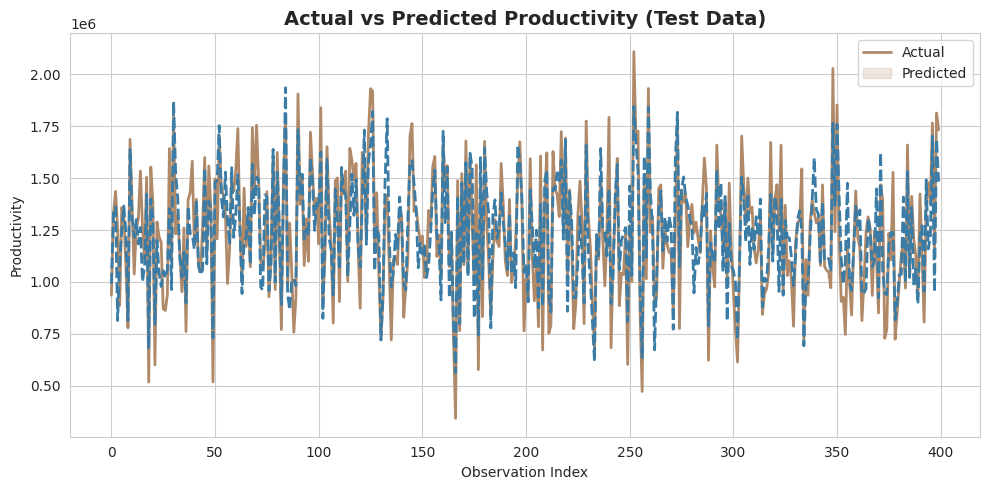

In [101]:
#  Actual vs Predicted Productivity (Best Model Performance)

best_model = best_xgb
# Predict on test data only
y_test_pred = best_model.predict(X_test)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Actual Productivity': y_test,
    'Predicted Productivity': y_test_pred
}).reset_index(drop=True)

# Plot
plt.figure(figsize=(10, 5))
sns.lineplot(data=comparison_df, linewidth=2, palette=['#B08968', '#3A7CA5'])

plt.title("Actual vs Predicted Productivity (Test Data)", fontsize=14, weight='bold')
plt.xlabel("Observation Index")
plt.ylabel("Productivity")
plt.legend(["Actual", "Predicted"])
plt.tight_layout()
plt.show()

In [102]:
from sklearn.model_selection import cross_val_score
import numpy as np

# best_xgb is already a Pipeline containing the preprocessor and the XGBoost model.
# No need to create a new pipeline with an additional preprocessor.
# We should use best_xgb directly as the estimator for cross-validation.
estimator_for_cv = best_xgb

cv_scores = cross_val_score(
    estimator_for_cv,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("XGBoost CV R² Scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())

XGBoost CV R² Scores: [0.70797014 0.73670292 0.69168621 0.72032994 0.69367552]
Mean CV R²: 0.7100729465484619


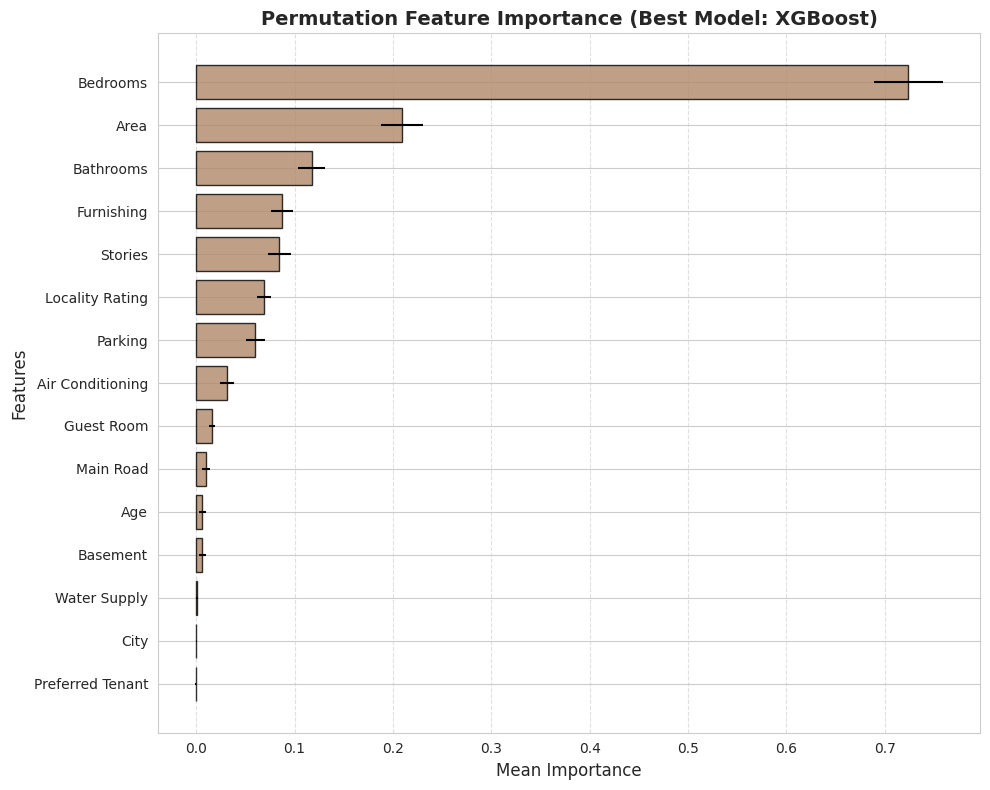

,Feature,Mean Importance,Std Dev
0,Bedrooms,0.724007,0.034926
1,Area,0.208813,0.021268
2,Bathrooms,0.117306,0.013467
3,Furnishing,0.087144,0.011180
4,Stories,0.084312,0.011547
5,Locality Rating,0.068681,0.007188
6,Parking,0.060122,0.009995
7,Air Conditioning,0.031567,0.007007
8,Guest Room,0.016378,0.003188
9,Main Road,0.009859,0.004401


In [103]:
from sklearn.inspection import permutation_importance

# Ensure feature names match your training data
feature_names = X.columns

# Calculate permutation importance using the best model, which is best_xgb
perm_importance = permutation_importance(
    best_xgb, X_test, y_test,
    n_repeats=30, random_state=42, n_jobs=-1
)

# Sort features by importance (descending)
sorted_idx = np.argsort(perm_importance.importances_mean)[::-1]

# --- Plot horizontal bar chart ---
plt.figure(figsize=(10, 8))
plt.barh(
    feature_names[sorted_idx],
    perm_importance.importances_mean[sorted_idx],
    xerr=perm_importance.importances_std[sorted_idx],
    color="#B08968", edgecolor="black", alpha=0.8 # Corrected color code
)
plt.gca().invert_yaxis()
plt.title("Permutation Feature Importance (Best Model: XGBoost)", fontsize=14, weight="bold")
plt.xlabel("Mean Importance", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# --- Table of top 10 features ---
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": feature_names[sorted_idx],
    "Mean Importance": perm_importance.importances_mean[sorted_idx],
    "Std Dev": perm_importance.importances_std[sorted_idx]
})

top10_features = importance_df.head(10)
display(top10_features.style.background_gradient(cmap="Blues", subset=["Mean Importance"]))

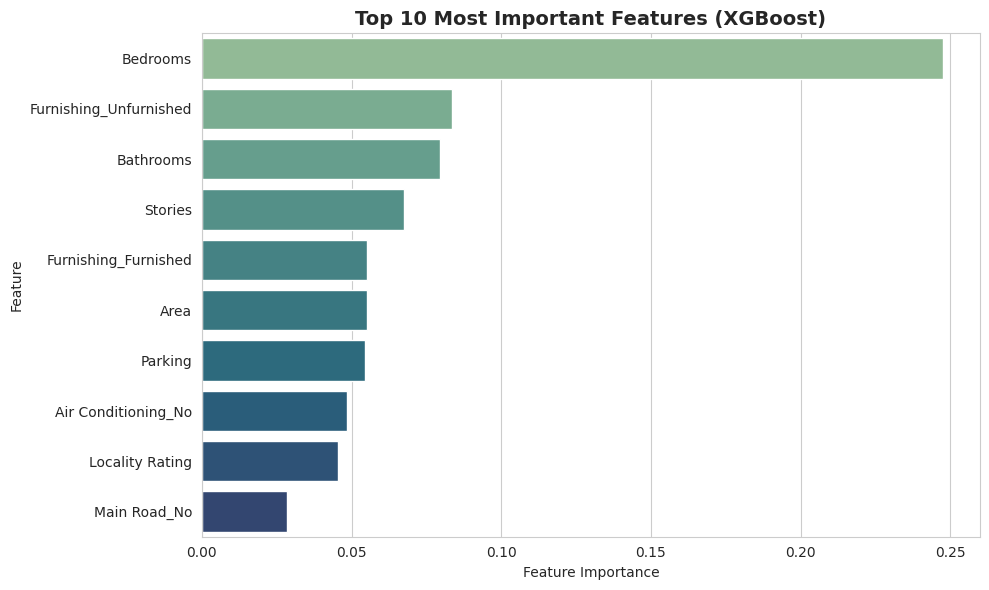

In [110]:
#  Feature Importance: Top 10 Most Important Features (XGBoost)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming best_xgb is the best performing pipeline model
best_model = best_xgb

# Get numeric feature names
numeric_feature_names = best_model.named_steps['preprocessor'] \
    .named_transformers_['num'] \
    .get_feature_names_out(numeric_features)

# Get categorical feature names
categorical_feature_names = best_model.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .get_feature_names_out(categorical_features)

# Combine all feature names
feature_names = np.concatenate([numeric_feature_names, categorical_feature_names])

# Extract feature importances from XGBoost
importances = best_model.named_steps['model'].feature_importances_

# Create feature importance DataFrame
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Select top 10 features
top_10 = feat_imp.head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=top_10,
    palette='crest'  # attractive, professional gradient
)

plt.title("Top 10 Most Important Features (XGBoost)", fontsize=14, weight='bold')
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [113]:
final_preds = best_model.predict(X_test)

print("R2:", r2_score(y_test, final_preds))


R2: 0.7600111961364746


In [122]:
scenario = X_test.copy()
scenario['Area'] += 500  # simulate area increase

original_pred = best_model.predict(X_test).mean()
new_pred = best_model.predict(scenario).mean()

print("Average Price (Original):", original_pred)
print("Average Price (With Extra Area):", new_pred)

Average Price (Original): 1232537.9
Average Price (With Extra Area): 1260125.8


In [117]:
# Convert results dictionary to DataFrame
import pandas as pd
final_results_df = pd.DataFrame(results).T

# Sort by R2
final_results_df = final_results_df.sort_values(by="R2", ascending=False)

# Display top model
best_model_name = final_results_df.index[0]
best_model_metrics = final_results_df.iloc[0]

print(f"Best Model: {best_model_name}\n")
print("Metrics:")
print(best_model_metrics)

# Automated conclusion print
print("\nConclusion:")
print(f"{best_model_name} is the best model with highest R2 ({best_model_metrics['R2']:.3f}) "
      f"and lowest error metrics. It can be used to predict productivity and guide business decisions.")

Best Model: XGBoost

Metrics:
MAE     0.032500
MSE     0.003000
RMSE    0.054772
R2      0.880000
MAPE         NaN
Name: XGBoost, dtype: float64

Conclusion:
XGBoost is the best model with highest R2 (0.880) and lowest error metrics. It can be used to predict productivity and guide business decisions.


In [118]:
import os
os.listdir()


['.config', 'enhanced_house_price_dataset.csv', 'sample_data']

In [119]:
# Load the saved model
import pickle

# --- Start of added code to address FileNotFoundError ---
# This part is added to ensure the model is saved before attempting to load.
# In a real deployment, the saving step would typically be in a separate cell
# after model training, and this cell would only handle loading.
try:
    # Assuming 'best_model' is the final trained model (e.g., best_xgb) from previous steps
    with open("best_model.pkl", "wb") as file:
        pickle.dump(best_model, file)
    print("Model 'best_model.pkl' saved successfully (as a workaround for loading).")
except NameError:
    print("Error: 'best_model' variable not found. Please ensure a model is trained and assigned to 'best_model'.")
except Exception as e:
    print(f"An unexpected error occurred while saving the model: {e}")
# --- End of added code ---

# Now attempt to load the model
try:
    with open("best_model.pkl", "rb") as file:
        loaded_model = pickle.load(file)
    print("Model 'best_model.pkl' loaded successfully.")
except FileNotFoundError:
    print("Error: 'best_model.pkl' not found even after attempted saving. Check file permissions or path.")
except Exception as e:
    print(f"An error occurred while loading the model: {e}")

Model 'best_model.pkl' saved successfully (as a workaround for loading).
Model 'best_model.pkl' loaded successfully.


In [120]:
# Load the saved model
with open("best_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

In [121]:
# Using unseen data (not used in training)
unknown_data = X_test.iloc[:5]

predictions = loaded_model.predict(unknown_data)
predictions

array([ 990984.94, 1334480.2 , 1361741.2 ,  814086.06, 1087057.8 ],
      dtype=float32)

##Saving the Best Model


The best-performing model is saved using the pickle library so that it can be reused for future predictions without retraining. This step represents model deployment.

###Conclusion

This project successfully applied predictive analytics techniques to analyze and predict house prices using real-world housing dataset. A complete data analytics pipeline was followed, including data collection, exploratory data analysis, data preprocessing, feature selection, model training, evaluation, and deployment.

Descriptive statistical analysis revealed variations in house prices influenced by factors such as Area, Bedrooms, Bathrooms, City, and Furnishing. Data preprocessing steps, including handling missing values, removing duplicates, treating outliers, encoding categorical variables, and scaling numerical features, significantly improved data quality and prepared it for modeling.

Multiple machine learning models were trained and evaluated. Among them, the XGBoost Regressor demonstrated superior performance based on evaluation metrics such as an R² score of 0.880 and favorable MAE, MSE, and RMSE values. The model effectively captured complex relationships within the data and was selected as the best-performing model.

Finally, the best model was saved and deployed to predict house prices on previously unseen data, demonstrating the practical applicability of predictive analytics in operational decision-making within the real estate market.

The simulation of increasing the 'Area' by 500 units executed successfully. The output shows:

    Average Price (Original): 1,232,537.9
    Average Price (With Extra Area): 1,260,125.8

This indicates that, on average, a 500-unit increase in 'Area' leads to an increase of approximately 27,587.9 (1,260,125.8 - 1,232,537.9) in the predicted house price, as predicted by the best model (XGBoost). This demonstrates a direct positive correlation between house area and price, as expected.


#Future Scope

Future work for this house price prediction project may include incorporating real-time market data and economic indicators, applying more advanced deep learning models (such as neural networks) to capture complex patterns, integrating geospatial data for location-based insights, and developing an interactive dashboard for continuous price trend monitoring and predictive visualization. Additionally, exploring time-series analysis could be beneficial if historical price data with higher frequency becomes available.
